# Лабораторная работа № 3

## Библиотеки

In [1]:
from mdp import MDP, FrozenLakeEnv, has_graphviz
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output  # для очистки вывода
from time import sleep

## Марковский процесс принятия решений

*transition_probs* - это словарь, который содержит словари состояний, которые содержат словари действий, которые в свою очередь содержат словари следующего состояния и вероятность попасть в него. Очевидно, сумма всех вероятностей равна 1. Если состояние не имеет действий, то тогда оно конечное

*param rewards* - это словарь из словарей состояний из словарей действий из словарей следующих состояний и вознаграждений, если в эти состояния попасть. Все неупомянутые вознаграждения по умолчанию равны 0

In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}

rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

In [3]:
mdp = MDP(transition_probs, rewards, initial_state='s0')

Проверки вывода

In [4]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print(f"next_state = {next_state}, reward = {reward}, done = {done}")
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

initial state = s0
next_state = s2, reward = 0.0, done = False
mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Визуализация графа

Graphviz available: True


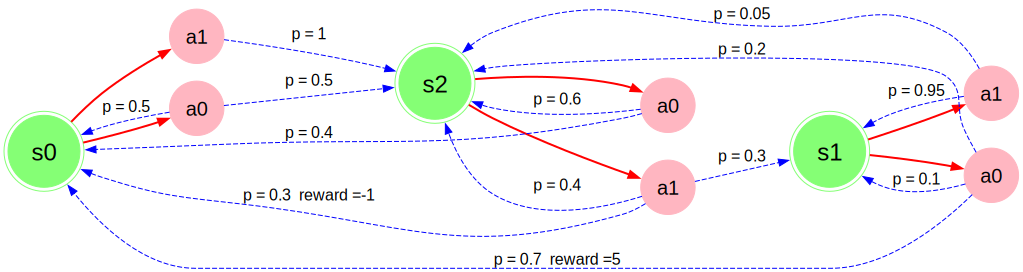

In [5]:
print("Graphviz available:", has_graphviz)

if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Итерации по значениям (Value Iterations, VI)

Инициализация для всех $s$

$$
V^{(0)}(s) = 0
$$

Затем для $i = 0, 1, 2, ...$ и для всех $s$

$$
V_{(i+1)}(s) = \max_a\sum_{s'}P(s'|s, a) · [r(s, a, s') + γV_i(s')]
$$

Определяем функцию для вычисления функции значения состояния-действия следующим образом

$$
Q_i(s, a) = \sum_{s'}P(s'|s, a) · [r(s, a, s') + γV_i(s')]
$$

Здесь

* $s$ - состояние в данный момент
* $s'$ - следующее состояние
* $a$ - действие, чтобы попасть в следующее состояние
* $P(s'|s, a)$ - вероятность попасть из $s$ в $s'$ через $a$
* $r(s, a, s')$ - вознаграждение за попадание в $s'$ от $s$ через $a$
* $V_i(s')$ - значение для $s'$ на предыдущей итерации
* $γ$ - дисконт

In [6]:
def get_action_value(mdp, state_values, state, action, gamma):
    Q = 0

    for next_state, prob in mdp.get_next_states(state, action).items():
        Q += prob * (mdp.get_reward(state, action, next_state) +  gamma * state_values[next_state])

    return Q

Тестируем

In [7]:
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Используя $Q(s, a)$, определяем следующую $V(s)$ для итерации значения

$$
V_{(i+1)}(s) = \max_a\sum_{s'}P(s'|s, a) · [r(s, a, s') + γV_i(s')] = \max_aQ_i(s, a)
$$

In [8]:
def get_new_state_value(mdp, state_values, state, gamma):
    if mdp.is_terminal(state):
        return 0
        
    return np.max([get_action_value(mdp, state_values, state, action, gamma) for action in mdp.get_possible_actions(state)])

Объединяем всё в рабочий алгоритм итерации значений

In [9]:
gamma = 0.9
num_iter = 100  # максимальное число итераций, кроме инициализации
min_difference = 0.001  # останавливаем VI, если новые значения ближе к старым менее чем это значение
state_values = {s: 0 for s in mdp.get_all_states()}  # инициализируем V(s)

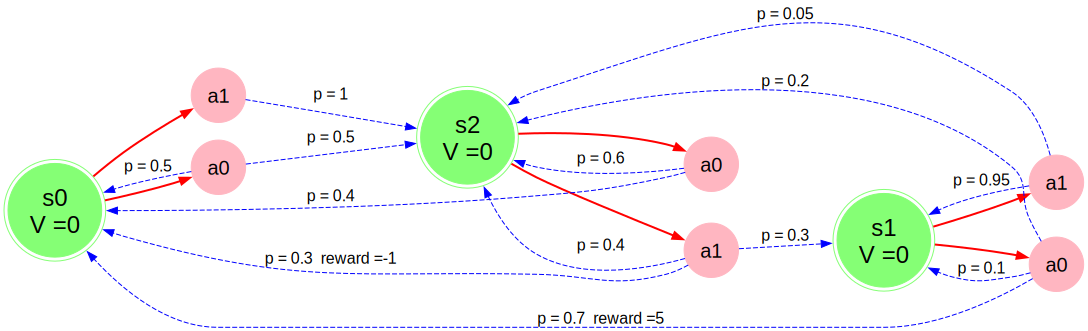

In [10]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

Вычисление новых значений состояния через вышеуказанные функции

In [11]:
for i in range(num_iter):
    new_state_values = {}

    for state in mdp.get_all_states():
        new_state_values[state] = get_new_state_value(mdp, state_values, state, gamma)

    assert isinstance(new_state_values, dict)  # проверка на тип словарь

    diff = np.max([np.abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states()])  # отклонения
    print(f"iter {i} | diff {diff}")

    for state, value in state_values.items():
        print(f"V({state}) = {value}")

    print()

    state_values = new_state_values  # обновление значений

    if diff < min_difference:  # проверка отклонения
        print("Terminated")
        break

iter 0 | diff 3.5
V(s0) = 0
V(s1) = 0
V(s2) = 0

iter 1 | diff 0.645
V(s0) = 0.0
V(s1) = 3.5
V(s2) = 0.0

iter 2 | diff 0.5805
V(s0) = 0.0
V(s1) = 3.815
V(s2) = 0.645

iter 3 | diff 0.4358204999999997
V(s0) = 0.5805
V(s1) = 3.95945
V(s2) = 0.9622499999999998

iter 4 | diff 0.306344025
V(s0) = 0.8660249999999998
V(s1) = 4.3952705
V(s2) = 1.2721965

iter 5 | diff 0.2757096225
V(s0) = 1.14497685
V(s1) = 4.670165464999999
V(s2) = 1.578540525

iter 6 | diff 0.24347110252050008
V(s0) = 1.4206864725
V(s1) = 4.92578760185
V(s2) = 1.8383630140499996

iter 7 | diff 0.21419250410938506
V(s0) = 1.6545267126449996
V(s1) = 5.1692587043705
V(s2) = 2.0753586851324997

iter 8 | diff 0.19277325369844678
V(s0) = 1.8678228166192496
V(s1) = 5.3811496756835435
V(s2) = 2.2895511892418847

iter 9 | diff 0.1732710404848179
V(s0) = 2.0605960703176964
V(s1) = 5.573151059345186
V(s2) = 2.4814610010488325

iter 10 | diff 0.15568887156157007
V(s0) = 2.2333149009439492
V(s1) = 5.746422099830004
V(s2) = 2.65443768538

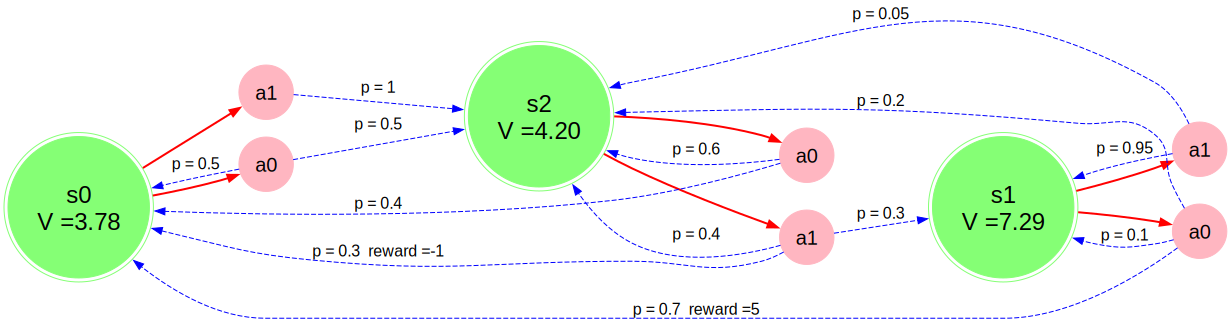

In [12]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [13]:
print("Final state values:", state_values)

Final state values: {'s0': np.float64(3.7810348735476405), 's1': np.float64(7.294006423867229), 's2': np.float64(4.202140275227048)}


Проверка вычислений

In [14]:
assert np.abs(state_values['s0'] - 3.781) < 0.01

In [15]:
assert np.abs(state_values['s1'] - 7.294) < 0.01

In [16]:
assert np.abs(state_values['s2'] - 4.202) < 0.01

### Поиск оптимальных действий

Используем эти значения для поиска оптимальных действий в каждом состоянии

$$
π^*(s) = argmax_a\sum_{s'}P(s'|s, a) · [r(s, a, s') + γV_i(s')] = argmax_aQ_i(s, a)
$$

Здесь $argmax$ т.к. нужно найти такое действие с максимальным $Q(s,a)$

In [17]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    if mdp.is_terminal(state):
        return None

    Q_a = [(get_action_value(mdp, state_values, state, action, gamma), action) for action in mdp.get_possible_actions(state)]

    return max(Q_a, key=lambda x: x[0])[1]

Проверка работы функции

In [18]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'

In [19]:
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'

In [20]:
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

Проверка правильной обработки отрицательных значений Q произвольной величины

In [21]:
assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0'

In [22]:
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1'

### Измерение среднего вознаграждения агента

In [23]:
state = mdp.reset()
rewards = []

In [24]:
for _ in range(10000):
    state, reward, done, _ = mdp.step(get_optimal_action(mdp, state_values, state, gamma))
    rewards.append(reward)

In [25]:
print("average reward:", np.mean(rewards))

average reward: 0.4892


In [26]:
assert (0.40 < np.mean(rewards) < 0.55)  # проверка среднего вознаграждения

## Среда Frozen Lake

Winter is here. You and your friends were tossing around a frisbee at the park
when you made a wild throw that left the frisbee out in the middle of the lake.
The water is mostly frozen, but there are a few holes where the ice has melted.
If you step into one of those holes, you'll fall into the freezing water.
At this time, there's an international frisbee shortage, so it's absolutely imperative that
you navigate across the lake and retrieve the disc.
However, the ice is slippery, so you won't always move in the direction you intend.
The surface is described using a grid like the following

```
    SFFF
    FHFH
    FFFH
    HFFG
```

S : starting point, safe
F : frozen surface, safe
H : hole, fall to your doom
G : goal, where the frisbee is located

The episode ends when you reach the goal or fall in a hole.
You receive a reward of 1 if you reach the goal, and zero otherwise.

In [27]:
mdp = FrozenLakeEnv(slip_chance=0)
mdp.render()

*FFF
FHFH
FFFH
HFFG



### Итерации по значениям (Value Iterations, VI)

То же, что и раньше, но в одной функции

In [28]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    if state_values is None:
        state_values = {s: 0 for s in mdp.get_all_states()}

    for i in range(num_iter):
        new_state_values = {}
    
        for state in mdp.get_all_states():
            new_state_values[state] = get_new_state_value(mdp, state_values, state, gamma)
    
        assert isinstance(new_state_values, dict)  # проверка на тип словарь
    
        diff = np.max([np.abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states()])  # отклонения
        print(f"iter {i} | diff {diff}")
    
        for state, value in state_values.items():
            print(f"V({state}) = {value}")
    
        print()
    
        state_values = new_state_values  # обновление значений
    
        if diff < min_difference:  # проверка отклонения
            print("Terminated")
            break

    return state_values

In [29]:
state_values = value_iteration(mdp)

iter 0 | diff 1.0
V((0, 0)) = 0
V((0, 1)) = 0
V((0, 2)) = 0
V((0, 3)) = 0
V((1, 0)) = 0
V((1, 1)) = 0
V((1, 2)) = 0
V((1, 3)) = 0
V((2, 0)) = 0
V((2, 1)) = 0
V((2, 2)) = 0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0
V((3, 2)) = 0
V((3, 3)) = 0

iter 1 | diff 0.9
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.0
V((3, 2)) = 1.0
V((3, 3)) = 0

iter 2 | diff 0.81
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.9
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.9
V((3, 2)) = 1.0
V((3, 3)) = 0

iter 3 | diff 0.7290000000000001
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.81
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.81
V((2, 2)) = 0.9
V((2, 3)) = 0
V((3,

### Оптимальные действия

In [30]:
state = mdp.reset()
mdp.render()

*FFF
FHFH
FFFH
HFFG



In [31]:
for t in range(100):
    action = get_optimal_action(mdp, state_values, state, gamma)
    print(action, end="\n\n")

    state, reward, done, _ = mdp.step(action)
    mdp.render()

    if done:
        break

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Визуализация

На графике будут отображены функции значений состояния и оптимальные действия на каждом шаге VI

In [32]:
def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()), color='g', size=12, verticalalignment='center', horizontalalignment='center', fontweight='bold')
            
            a = Pi[y, x]
            
            if a is None:
                continue
                
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m', head_width=0.1, head_length=0.1)
            
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 9
iter 0 | diff 0.0
V((0, 0)) = 0.5904900000000002
V((0, 1)) = 0.6561000000000001
V((0, 2)) = 0.7290000000000001
V((0, 3)) = 0.6561000000000001
V((1, 0)) = 0.6561000000000001
V((1, 1)) = 0
V((1, 2)) = 0.81
V((1, 3)) = 0
V((2, 0)) = 0.7290000000000001
V((2, 1)) = 0.81
V((2, 2)) = 0.9
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.9
V((3, 2)) = 1.0
V((3, 3)) = 0

Terminated


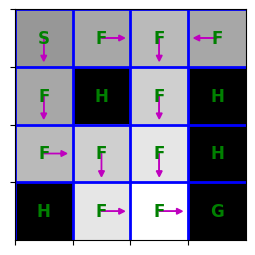

In [33]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    clear_output(True)
    print(f"after iteration {i}")
    state_values = value_iteration(mdp, state_values, num_iter=1)  # не обращать внимания на итерацию 0 на каждом шаге
    draw_policy(mdp, state_values)

after iteration 29
iter 0 | diff 7.73146544286174e-08
V((0, 0)) = 0.19816835624695936
V((0, 1)) = 0.2223445049935264
V((0, 2)) = 0.24939384969723666
V((0, 3)) = 0.2796305097148703
V((0, 4)) = 0.31337222379310753
V((0, 5)) = 0.3501900589624752
V((0, 6)) = 0.3911877019971599
V((0, 7)) = 0.4341019274188376
V((1, 0)) = 0.203373521905427
V((1, 1)) = 0.22955576785721
V((1, 2)) = 0.2593427579271444
V((1, 3)) = 0.293680865071797
V((1, 4)) = 0.3470339433789346
V((1, 5)) = 0.3904326256868325
V((1, 6)) = 0.4393760034943558
V((1, 7)) = 0.49007888167744673
V((2, 0)) = 0.18924037190332485
V((2, 1)) = 0.21072556357547825
V((2, 2)) = 0.22752308507941132
V((2, 3)) = 0
V((2, 4)) = 0.37070593434159904
V((2, 5)) = 0.41732245382073924
V((2, 6)) = 0.4935222045832375
V((2, 7)) = 0.5533992739049909
V((3, 0)) = 0.20890902758592897
V((3, 1)) = 0.23700150307533097
V((3, 2)) = 0.26918572731282375
V((3, 3)) = 0.3070479512895303
V((3, 4)) = 0.37907154484477706
V((3, 5)) = 0
V((3, 6)) = 0.5553576874710385
V((3, 7)) 

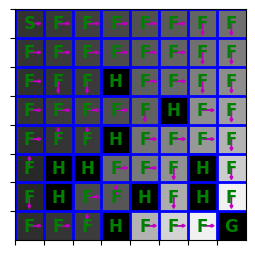

In [34]:
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print(f"after iteration {i}")
    state_values = value_iteration(mdp, state_values, num_iter=1)  # не обращать внимания на итерацию 0 на каждом шаге
    draw_policy(mdp, state_values)
    sleep(0.5)

### Массовые испытания

In [35]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)
total_rewards = []

iter 0 | diff 1.0
V((0, 0)) = 0
V((0, 1)) = 0
V((0, 2)) = 0
V((0, 3)) = 0
V((1, 0)) = 0
V((1, 1)) = 0
V((1, 2)) = 0
V((1, 3)) = 0
V((2, 0)) = 0
V((2, 1)) = 0
V((2, 2)) = 0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0
V((3, 2)) = 0
V((3, 3)) = 0

iter 1 | diff 0.9
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.0
V((3, 2)) = 1.0
V((3, 3)) = 0

iter 2 | diff 0.81
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.9
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.9
V((3, 2)) = 1.0
V((3, 3)) = 0

iter 3 | diff 0.7290000000000001
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.81
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.81
V((2, 2)) = 0.9
V((2, 3)) = 0
V((3,

In [36]:
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

In [37]:
print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

average reward:  1.0
Well done!


In [38]:
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)
total_rewards = []

iter 0 | diff 0.9
V((0, 0)) = 0
V((0, 1)) = 0
V((0, 2)) = 0
V((0, 3)) = 0
V((1, 0)) = 0
V((1, 1)) = 0
V((1, 2)) = 0
V((1, 3)) = 0
V((2, 0)) = 0
V((2, 1)) = 0
V((2, 2)) = 0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0
V((3, 2)) = 0
V((3, 3)) = 0

iter 1 | diff 0.7290000000000001
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.0
V((3, 2)) = 0.9
V((3, 3)) = 0

iter 2 | diff 0.6232950000000002
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.7290000000000001
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.7290000000000001
V((3, 2)) = 0.9405
V((3, 3)) = 0

iter 3 | diff 0.5048689500000001
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.5904900000000002
V((1, 

In [39]:
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

In [40]:
print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

average reward:  0.876
Well done!


In [41]:
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)
total_rewards = []

iter 0 | diff 0.75
V((0, 0)) = 0
V((0, 1)) = 0
V((0, 2)) = 0
V((0, 3)) = 0
V((1, 0)) = 0
V((1, 1)) = 0
V((1, 2)) = 0
V((1, 3)) = 0
V((2, 0)) = 0
V((2, 1)) = 0
V((2, 2)) = 0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0
V((3, 2)) = 0
V((3, 3)) = 0

iter 1 | diff 0.5062500000000001
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.0
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.0
V((3, 2)) = 0.75
V((3, 3)) = 0

iter 2 | diff 0.39867187500000006
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.0
V((1, 3)) = 0
V((2, 0)) = 0.0
V((2, 1)) = 0.0
V((2, 2)) = 0.5062500000000001
V((2, 3)) = 0
V((3, 0)) = 0
V((3, 1)) = 0.5062500000000001
V((3, 2)) = 0.834375
V((3, 3)) = 0

iter 3 | diff 0.269103515625
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0, 3)) = 0.0
V((1, 0)) = 0.0
V((1, 1)) = 0
V((1, 2)) = 0.34171875000000007
V((1

In [42]:
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

In [43]:
print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

average reward:  0.636
Well done!


In [44]:
mdp = FrozenLakeEnv(slip_chance=0.2, map_name="8x8")
state_values = value_iteration(mdp)
total_rewards = []

iter 0 | diff 0.8
V((0, 0)) = 0
V((0, 1)) = 0
V((0, 2)) = 0
V((0, 3)) = 0
V((0, 4)) = 0
V((0, 5)) = 0
V((0, 6)) = 0
V((0, 7)) = 0
V((1, 0)) = 0
V((1, 1)) = 0
V((1, 2)) = 0
V((1, 3)) = 0
V((1, 4)) = 0
V((1, 5)) = 0
V((1, 6)) = 0
V((1, 7)) = 0
V((2, 0)) = 0
V((2, 1)) = 0
V((2, 2)) = 0
V((2, 3)) = 0
V((2, 4)) = 0
V((2, 5)) = 0
V((2, 6)) = 0
V((2, 7)) = 0
V((3, 0)) = 0
V((3, 1)) = 0
V((3, 2)) = 0
V((3, 3)) = 0
V((3, 4)) = 0
V((3, 5)) = 0
V((3, 6)) = 0
V((3, 7)) = 0
V((4, 0)) = 0
V((4, 1)) = 0
V((4, 2)) = 0
V((4, 3)) = 0
V((4, 4)) = 0
V((4, 5)) = 0
V((4, 6)) = 0
V((4, 7)) = 0
V((5, 0)) = 0
V((5, 1)) = 0
V((5, 2)) = 0
V((5, 3)) = 0
V((5, 4)) = 0
V((5, 5)) = 0
V((5, 6)) = 0
V((5, 7)) = 0
V((6, 0)) = 0
V((6, 1)) = 0
V((6, 2)) = 0
V((6, 3)) = 0
V((6, 4)) = 0
V((6, 5)) = 0
V((6, 6)) = 0
V((6, 7)) = 0
V((7, 0)) = 0
V((7, 1)) = 0
V((7, 2)) = 0
V((7, 3)) = 0
V((7, 4)) = 0
V((7, 5)) = 0
V((7, 6)) = 0
V((7, 7)) = 0

iter 1 | diff 0.5760000000000001
V((0, 0)) = 0.0
V((0, 1)) = 0.0
V((0, 2)) = 0.0
V((0

In [45]:
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

In [46]:
print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

average reward:  0.744
Well done!
